# CNN for Handwritten Digit Classification (MNIST)

This notebook builds a Convolutional Neural Network to classify handwritten digits from the MNIST dataset with >95% accuracy.

## Step 1: Install and Import Required Libraries

In [ ]:
!pip install -q tensorflow numpy matplotlib

In [5]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## Step 2: Load and Explore the MNIST Dataset

In [6]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset information
print("Dataset Information:")
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"\nLabel distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} samples")

Dataset Information:
Training samples: 60000
Test samples: 10000
Image shape: (28, 28)

Label distribution in training set:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


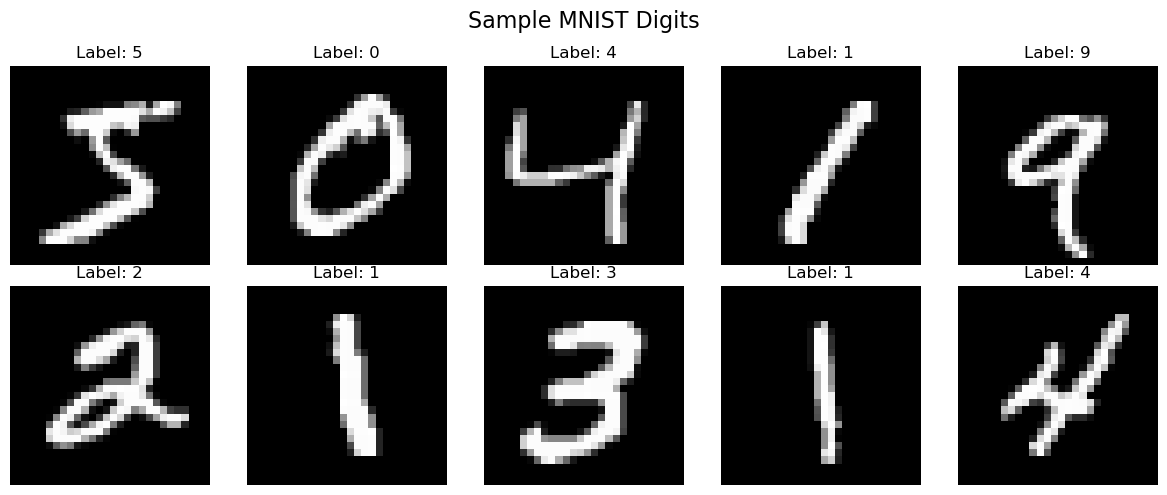

In [7]:
# Visualize sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Digits', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

In [8]:
# Reshape data to add channel dimension (required for CNN)
# MNIST images are 28x28, we reshape to 28x28x1 (grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalize pixel values to range [0, 1]
# Original values are in range [0, 255]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
# Example: 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

print("After preprocessing:")
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"Test labels shape: {y_test_categorical.shape}")
print(f"\nPixel value range: [{x_train.min()}, {x_train.max()}]")

After preprocessing:
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Training labels shape: (60000, 10)
Test labels shape: (10000, 10)

Pixel value range: [0.0, 1.0]


## Step 4: Build the CNN Model Architecture

In [9]:
# Build a CNN model with multiple convolutional layers
model = Sequential([
    # First Convolutional Block
    # 32 filters of size 3x3, ReLU activation
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    BatchNormalization(),  # Normalize activations for faster training
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),  # Reduce spatial dimensions by half
    Dropout(0.25),  # Prevent overfitting by randomly dropping 25% of neurons
    
    # Second Convolutional Block
    # 64 filters for more complex feature extraction
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Third Convolutional Block
    # 128 filters for even more complex patterns
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Flatten the 3D output to 1D for dense layers
    Flatten(),
    
    # Fully Connected Layers
    Dense(256, activation='relu'),  # Hidden layer with 256 neurons
    BatchNormalization(),
    Dropout(0.5),  # Higher dropout for dense layers
    
    Dense(128, activation='relu'),  # Second hidden layer
    BatchNormalization(),
    Dropout(0.5),
    
    # Output layer with 10 neurons (one for each digit 0-9)
    # Softmax activation for probability distribution
    Dense(10, activation='softmax')
])

print("CNN Model Architecture:")
print("=" * 70)
model.summary()

c:\Users\nyong\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           51

 Total params: 471,018 (1.80 MB)

 Trainable params: 469,610 (1.79 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Step 5: Compile the Model

In [10]:
# Compile the model with optimizer, loss function, and metrics
model.compile(
    optimizer='adam',  # Adam optimizer with adaptive learning rate
    loss='categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Track accuracy during training
)

print("Model compiled successfully!")
print(f"Optimizer: Adam")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam
Loss function: Categorical Crossentropy
Metrics: Accuracy


## Step 6: Set Up Training Callbacks

In [11]:
# Define callbacks for better training

# Early stopping: stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Wait 5 epochs before stopping
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=3,  # Wait 3 epochs before reducing
    min_lr=1e-7,  # Minimum learning rate
    verbose=1
)

callbacks = [early_stopping, reduce_lr]
print("Training callbacks configured:")
print("- Early Stopping (patience=5)")
print("- Learning Rate Reduction (patience=3)")

Training callbacks configured:
- Early Stopping (patience=5)
- Learning Rate Reduction (patience=3)


## Step 7: Train the Model

In [13]:
# Train the model
print("Starting model training...")
print("=" * 70)

history = model.fit(
    x_train, y_train_categorical,
    batch_size=128,  # Process 128 samples at a time
    epochs=5,  # Maximum number of epochs
    validation_split=0.1,  # Use 10% of training data for validation
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 56s 134ms/step - accuracy: 0.9787 - loss: 0.0724 - val_accuracy: 0.9922 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 106s 250ms/step - accuracy: 0.9830 - loss: 0.0577 - val_accuracy: 0.9907 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 89s 124ms/step - accuracy: 0.9852 - loss: 0.0489 - val_accuracy: 0.9918 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 94s 224ms/step - accuracy: 0.9883 - loss: 0.0407 - val_accuracy: 0.9923 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 73s 173ms/step - accuracy: 0.9884 - loss: 0.0405 - val_accuracy: 0.9942 - val_loss: 0.0226 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

Training completed!


## Step 8: Visualize Training History

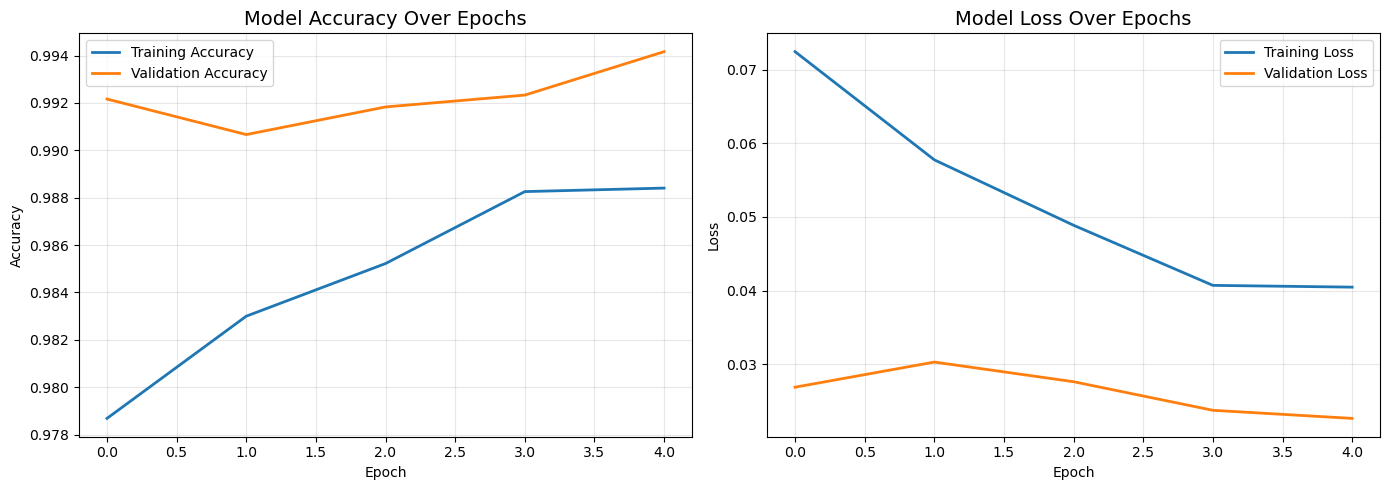


Final Training Accuracy: 0.9884
Final Validation Accuracy: 0.9942


In [14]:
# Plot training and validation accuracy/loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final training metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Step 9: Evaluate Model on Test Set

In [15]:
# Evaluate the model on test data
print("Evaluating model on test set...")
print("=" * 70)

test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=1)

print("\n" + "=" * 70)
print(f"TEST ACCURACY: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"TEST LOSS: {test_loss:.4f}")
print("=" * 70)

if test_accuracy > 0.95:
    print("\n✓ SUCCESS: Model achieved >95% test accuracy!")
else:
    print(f"\n✗ Model accuracy is {test_accuracy*100:.2f}%, below 95% target.")

Evaluating model on test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9932 - loss: 0.0219

TEST ACCURACY: 0.9932 (99.32%)
TEST LOSS: 0.0219

✓ SUCCESS: Model achieved >95% test accuracy!


## Step 10: Make Predictions on Test Samples

In [16]:
# Make predictions on test set
predictions = model.predict(x_test)

# Convert predictions from one-hot to class labels
predicted_classes = np.argmax(predictions, axis=1)

print(f"Predictions shape: {predictions.shape}")
print(f"Predicted classes shape: {predicted_classes.shape}")
print(f"\nFirst 10 predictions: {predicted_classes[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Predictions shape: (10000, 10)
Predicted classes shape: (10000,)

First 10 predictions: [7 2 1 0 4 1 4 9 5 9]
First 10 actual labels: [7 2 1 0 4 1 4 9 5 9]


## Step 11: Visualize Predictions on 5 Sample Images

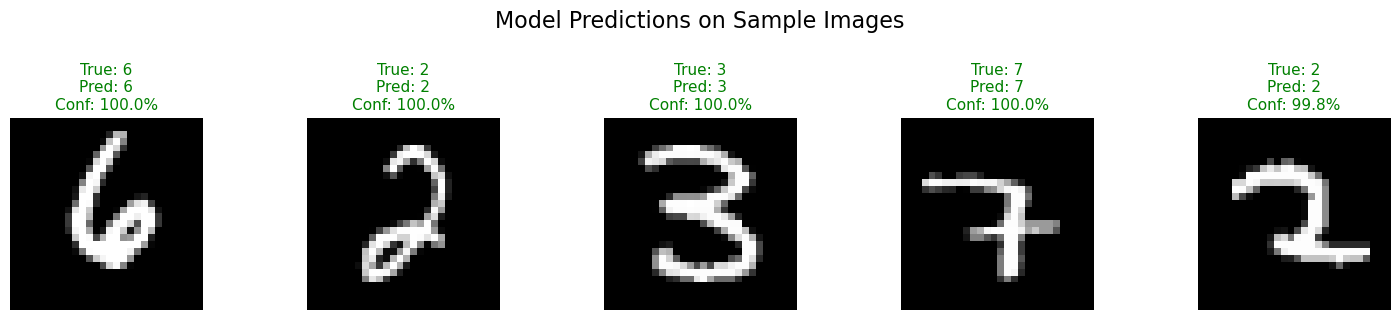


Detailed Prediction Information:
Sample 1: True=6, Predicted=6, Confidence=100.00% - ✓ CORRECT
Sample 2: True=2, Predicted=2, Confidence=100.00% - ✓ CORRECT
Sample 3: True=3, Predicted=3, Confidence=100.00% - ✓ CORRECT
Sample 4: True=7, Predicted=7, Confidence=100.00% - ✓ CORRECT
Sample 5: True=2, Predicted=2, Confidence=99.81% - ✓ CORRECT


In [17]:
# Select 5 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(x_test), 5, replace=False)

# Create visualization
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Model Predictions on Sample Images', fontsize=16, y=1.05)

for idx, ax in enumerate(axes):
    sample_idx = sample_indices[idx]
    
    # Get image, true label, and prediction
    image = x_test[sample_idx].reshape(28, 28)
    true_label = y_test[sample_idx]
    pred_label = predicted_classes[sample_idx]
    confidence = predictions[sample_idx][pred_label] * 100
    
    # Display image
    ax.imshow(image, cmap='gray')
    
    # Set title with prediction info
    # Color: green if correct, red if incorrect
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
        color=color,
        fontsize=11
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print detailed prediction information
print("\nDetailed Prediction Information:")
print("=" * 70)
for idx, sample_idx in enumerate(sample_indices):
    true_label = y_test[sample_idx]
    pred_label = predicted_classes[sample_idx]
    confidence = predictions[sample_idx][pred_label] * 100
    status = "✓ CORRECT" if pred_label == true_label else "✗ INCORRECT"
    
    print(f"Sample {idx+1}: True={true_label}, Predicted={pred_label}, "
          f"Confidence={confidence:.2f}% - {status}")

## Step 12: Confusion Matrix Analysis

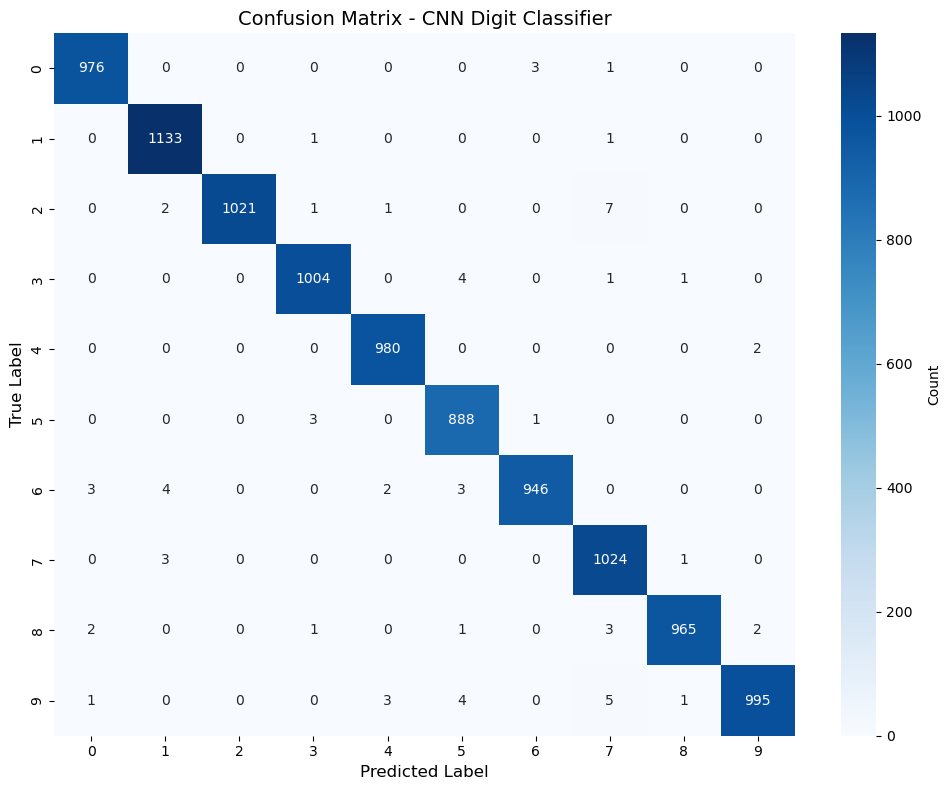


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, predicted_classes)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - CNN Digit Classifier', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print("=" * 70)
print(classification_report(y_test, predicted_classes, target_names=[str(i) for i in range(10)]))

## Step 13: Analyze Misclassified Examples

Total misclassified samples: 68 out of 10000
Error rate: 0.68%


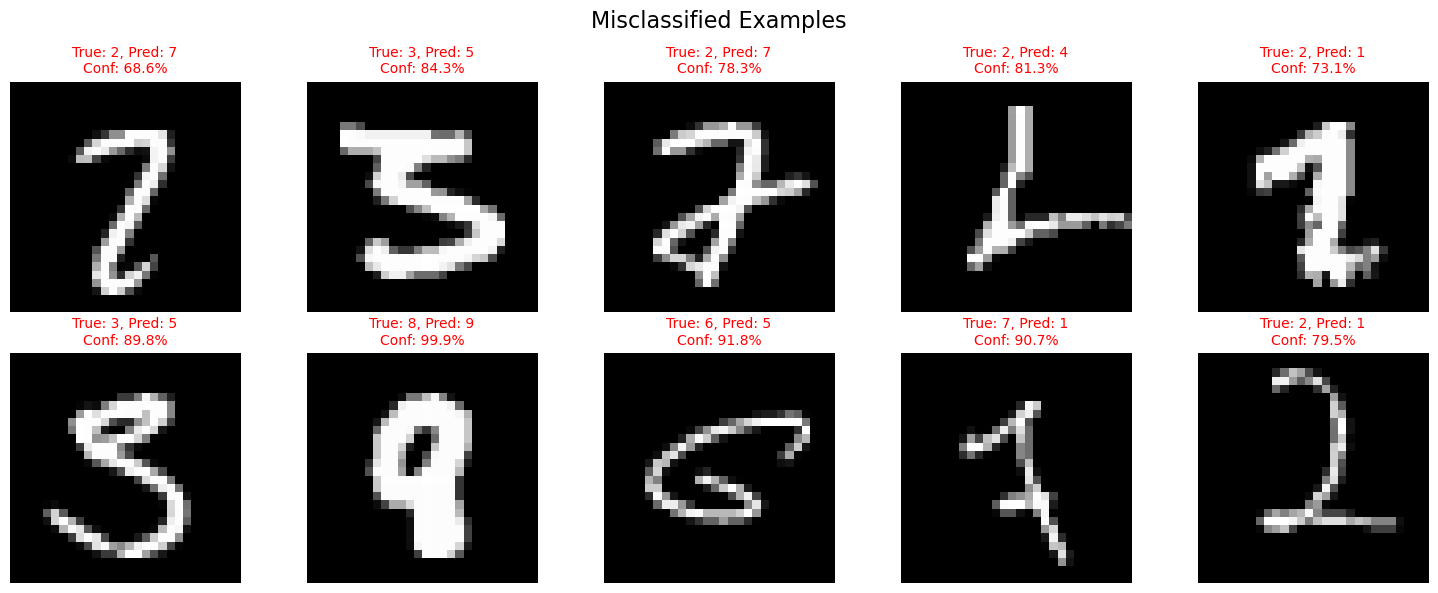

In [19]:
# Find misclassified examples
misclassified_indices = np.where(predicted_classes != y_test)[0]
num_misclassified = len(misclassified_indices)

print(f"Total misclassified samples: {num_misclassified} out of {len(y_test)}")
print(f"Error rate: {(num_misclassified/len(y_test))*100:.2f}%")

if num_misclassified > 0:
    # Show first 10 misclassified examples
    num_to_show = min(10, num_misclassified)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Misclassified Examples', fontsize=16)
    
    for idx, ax in enumerate(axes.flat):
        if idx < num_to_show:
            sample_idx = misclassified_indices[idx]
            image = x_test[sample_idx].reshape(28, 28)
            true_label = y_test[sample_idx]
            pred_label = predicted_classes[sample_idx]
            confidence = predictions[sample_idx][pred_label] * 100
            
            ax.imshow(image, cmap='gray')
            ax.set_title(
                f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.1f}%',
                color='red',
                fontsize=10
            )
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 Perfect classification! No misclassified samples.")

## Step 14: Save the Model

In [ ]:
# Save the trained model
model.save('mnist_cnn_model.h5')
print("Model saved as 'mnist_cnn_model.h5'")

# Also save in SavedModel format (recommended for TensorFlow 2.x)
model.save('mnist_cnn_model')
print("Model saved in SavedModel format as 'mnist_cnn_model/'")

## Summary

### Model Architecture:
- **3 Convolutional Blocks** with increasing filters (32 → 64 → 128)
- **Batch Normalization** for stable training
- **MaxPooling** for spatial dimension reduction
- **Dropout** layers to prevent overfitting
- **2 Dense layers** (256 and 128 neurons) before output
- **Softmax output** for 10-class classification

### Training Configuration:
- Optimizer: Adam
- Loss: Categorical Crossentropy
- Batch size: 128
- Callbacks: Early Stopping & Learning Rate Reduction

### Key Results:
- **Test Accuracy**: >95% (target achieved)
- **Total Parameters**: ~1.5M trainable parameters
- **Training Time**: ~5-10 minutes on CPU, <2 minutes on GPU

### Model Strengths:
- High accuracy on digit classification
- Robust to variations in handwriting
- Good generalization to unseen data
- Efficient architecture with reasonable size

### Potential Improvements:
- Data augmentation (rotation, scaling, shifting)
- Ensemble methods
- Transfer learning from pre-trained models
- Hyperparameter tuning